In [51]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [53]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    download = True
)


In [55]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [57]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [59]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [61]:
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader(train_data,
                        batch_size = 100,
                        shuffle=True,
                        num_workers=1),
    'test': DataLoader(test_data,
                      batch_size = 100,
                      shuffle=True,
                      num_workers=1),
}

In [63]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x1464736d0>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x145a35c50>}

In [65]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)

        return F.softmax(x)

In [67]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f"Train Epoch: epoch {epoch} [{batch_idx * len(data)}/{len(loaders['train'].dataset) } ({100. * batch_idx / len(loaders['train']):.0f}%)]\t{loss.item():.6f}")

def test():
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(loaders['test'].dataset)
    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy {correct}/{len(loaders['test'].dataset)} ({100. * correct / len(loaders['test'].dataset):.0f}%\n)")

In [69]:
for epoch in range(1, 11):
    train(epoch)
    test()

/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <E03EDA44-89AE-3115-9796-62BA9E0E2EDE> /Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <ADD14A6E-669F-3F53-A802-D8FBD6AA3F40> /Users/fde645/Documents/batman/anaconda3/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/var/folders/41/6v057w616715smxxhvd_xcgc0000gn/T/ipykernel_28451/1111962521.py:22: UserWarning: Implicit dimension choice for softmax has been deprecated. Chang

Train Epoch: epoch 1 [0/60000 (0%)]	2.303578
Train Epoch: epoch 1 [2000/60000 (3%)]	2.294473
Train Epoch: epoch 1 [4000/60000 (7%)]	2.122511
Train Epoch: epoch 1 [6000/60000 (10%)]	1.956147
Train Epoch: epoch 1 [8000/60000 (13%)]	1.876745
Train Epoch: epoch 1 [10000/60000 (17%)]	1.817377
Train Epoch: epoch 1 [12000/60000 (20%)]	1.736086
Train Epoch: epoch 1 [14000/60000 (23%)]	1.754582
Train Epoch: epoch 1 [16000/60000 (27%)]	1.777221
Train Epoch: epoch 1 [18000/60000 (30%)]	1.776625
Train Epoch: epoch 1 [20000/60000 (33%)]	1.728489
Train Epoch: epoch 1 [22000/60000 (37%)]	1.661175
Train Epoch: epoch 1 [24000/60000 (40%)]	1.640434
Train Epoch: epoch 1 [26000/60000 (43%)]	1.643074
Train Epoch: epoch 1 [28000/60000 (47%)]	1.653587
Train Epoch: epoch 1 [30000/60000 (50%)]	1.733629
Train Epoch: epoch 1 [32000/60000 (53%)]	1.684507
Train Epoch: epoch 1 [34000/60000 (57%)]	1.643283
Train Epoch: epoch 1 [36000/60000 (60%)]	1.621031
Train Epoch: epoch 1 [38000/60000 (63%)]	1.647702
Train Epoch

/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <E03EDA44-89AE-3115-9796-62BA9E0E2EDE> /Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <ADD14A6E-669F-3F53-A802-D8FBD6AA3F40> /Users/fde645/Documents/batman/anaconda3/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



Test set: Average loss: 0.0153, Accuracy 9370/10000 (94%
)


/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <E03EDA44-89AE-3115-9796-62BA9E0E2EDE> /Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <ADD14A6E-669F-3F53-A802-D8FBD6AA3F40> /Users/fde645/Documents/batman/anaconda3/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


...


Test set: Average loss: 0.0149, Accuracy 9720/10000 (97%
)


/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <E03EDA44-89AE-3115-9796-62BA9E0E2EDE> /Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <ADD14A6E-669F-3F53-A802-D8FBD6AA3F40> /Users/fde645/Documents/batman/anaconda3/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Train Epoch: epoch 10 [0/60000 (0%)]	1.513873
Train Epoch: epoch 10 [2000/60000 (3%)]	1.548247
Train Epoch: epoch 10 [4000/60000 (7%)]	1.515344
Train Epoch: epoch 10 [6000/60000 (10%)]	1.517556
Train Epoch: epoch 10 [8000/60000 (13%)]	1.493969
Train Epoch: epoch 10 [10000/60000 (17%)]	1.512354
Train Epoch: epoch 10 [12000/60000 (20%)]	1.504837
Train Epoch: epoch 10 [14000/60000 (23%)]	1.489979
Train Epoch: epoch 10 [16000/60000 (27%)]	1.507773
Train Epoch: epoch 10 [18000/60000 (30%)]	1.515820
Train Epoch: epoch 10 [20000/60000 (33%)]	1.532975
Train Epoch: epoch 10 [22000/60000 (37%)]	1.533152
Train Epoch: epoch 10 [24000/60000 (40%)]	1.589697
Train Epoch: epoch 10 [26000/60000 (43%)]	1.542136
Train Epoch: epoch 10 [28000/60000 (47%)]	1.526521
Train Epoch: epoch 10 [30000/60000 (50%)]	1.548784
Train Epoch: epoch 10 [32000/60000 (53%)]	1.495576
Train Epoch: epoch 10 [34000/60000 (57%)]	1.546585
Train Epoch: epoch 10 [36000/60000 (60%)]	1.534045
Train Epoch: epoch 10 [38000/60000 (63%)]	

/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <E03EDA44-89AE-3115-9796-62BA9E0E2EDE> /Users/fde645/Documents/batman/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <ADD14A6E-669F-3F53-A802-D8FBD6AA3F40> /Users/fde645/Documents/batman/anaconda3/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



Test set: Average loss: 0.0149, Accuracy 9726/10000 (97%
)


/var/folders/41/6v057w616715smxxhvd_xcgc0000gn/T/ipykernel_28451/1111962521.py:22: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Prediction: 2


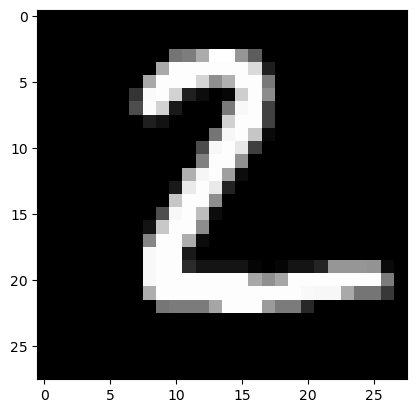

In [79]:
import matplotlib.pyplot as plt

model.eval()

data, target = test_data[1]

data = data.unsqueeze(0).to(device)

output = model(data)
prediction = output.argmax(dim=1, keepdim=True).item()
print(f'Prediction: {prediction}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')
plt.show()

